# mHealth Dataset 기반 RNN 분류

## 결과 분석  

Test accuracy: 81.23%

mHealth 데이터셋을 SimpleRNN 기반 모델로 학습한 결과 정확도는 81.23%로 나타났다.

Train accuracy는 92.23%, Test accuracy는 81.23%로 약 11%의 차이가 발생하여 과적합 경향이 확인된다.

SimpleRNN은 시간 순서 정보를 학습할 수 있지만 긴 시계열에서 중요한 정보를 오래 유지하는 능력이 부족하기 때문에 mHealth 데이터의 복잡한 움직임 패턴을 충분히 학습하는 데 한계가 있는 것으로 판단된다.

따라서 mHealth 데이터셋에서는 SimpleRNN보다 중요한 정보를 오래 유지할 수 있는  LSTM 또는 GRU 구조가 더 적합하다고 판단된다.

In [ ]:
# 라이브러리 import
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# mHealth raw 데이터 로드
base_dir = "/content/drive/MyDrive"

FEATURE_COLUMNS = [f'sensor_{i+1}' for i in range(23)]
LABEL_COLUMN = 'label'
SUBJECT_COLUMN = 'subject'

LABELS = [
    'Standing still',
    'Sitting and relaxing',
    'Lying down',
    'Walking',
    'Climbing stairs',
    'Waist bends forward',
    'Frontal elevation of arms',
    'Knees bending',
    'Cycling',
    'Jogging',
    'Running',
    'Jump front and back'
]

dfs = []

for i in range(1, 11):
    path = os.path.join(base_dir, f"mHealth_subject{i}.log")

    df_i = pd.read_csv(path, sep=r"\s+", header=None)
    df_i.columns = FEATURE_COLUMNS + [LABEL_COLUMN]
    df_i[SUBJECT_COLUMN] = i

    dfs.append(df_i)

data = pd.concat(dfs, ignore_index=True)

print(data.shape)
print(data.head())

(1215745, 25)
   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  \
0   -9.8184  0.009971   0.29563  0.004186  0.004186    2.1849   -9.6967   
1   -9.8489  0.524040   0.37348  0.004186  0.016745    2.3876   -9.5080   
2   -9.6602  0.181850   0.43742  0.016745  0.037677    2.4086   -9.5674   
3   -9.6507  0.214220   0.24033  0.079540  0.117220    2.1814   -9.4301   
4   -9.7030  0.303890   0.31156  0.221870  0.205130    2.4173   -9.3889   

   sensor_8  sensor_9  sensor_10  ...  sensor_16  sensor_17  sensor_18  \
0   0.63077  0.103900   -0.84053  ...    -4.5781   0.187760   -0.44902   
1   0.68389  0.085343   -0.83865  ...    -4.3198   0.023595   -0.44902   
2   0.68113  0.085343   -0.83865  ...    -4.2772   0.275720   -0.44902   
3   0.55031  0.085343   -0.83865  ...    -4.3163   0.367520   -0.45686   
4   0.71098  0.085343   -0.83865  ...    -4.1459   0.407290   -0.45686   

   sensor_19  sensor_20  sensor_21  sensor_22  sensor_23  label  subject  
0    -1.0103   

## 데이터 전처리

1. **mHealth 로그 파일 로드**
2. **클린업**: 라벨 0 제거, 23개 센서 컬럼을 float32로 변환
3. **Label Encoding**: mHealth activity 이름을 정수 라벨로 변환
4. **Data Split (subject 기반)**:
  - subject 1~7: train
  - subject 8: validation
  - subject 9~10: test
5. **정규화**: StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation**: sliding window (TIME_STEPS=200, STEP=40)


In [ ]:
# 클린업
# 라벨 0은 비활동/전환 구간이므로 실제 12개 activity만 사용
df = data[data[LABEL_COLUMN] > 0].copy()

# 센서 값을 float32 숫자형으로 변환
for col in FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(np.int32)
df[SUBJECT_COLUMN] = df[SUBJECT_COLUMN].astype(np.int32)
df = df.dropna().reset_index(drop=True)

# 라벨 번호를 activity 이름으로 변환
df['activity'] = df[LABEL_COLUMN].map(lambda label: LABELS[label - 1])

In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print()
print('Label mapping:', dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Climbing stairs', 1: 'Cycling', 2: 'Frontal elevation of arms', 3: 'Jogging', 4: 'Jump front and back', 5: 'Knees bending', 6: 'Lying down', 7: 'Running', 8: 'Sitting and relaxing', 9: 'Standing still', 10: 'Waist bends forward', 11: 'Walking'}


In [ ]:
# Data Split (subject 기반)
# subject 1~7 = train set
# subject 8 = validation set
# subject 9~10 = test set
TRAIN_SUBJECTS = list(range(1, 8))
VAL_SUBJECTS = [8]
TEST_SUBJECTS = [9, 10]

df_train = df[df[SUBJECT_COLUMN].isin(TRAIN_SUBJECTS)].copy()
df_val   = df[df[SUBJECT_COLUMN].isin(VAL_SUBJECTS)].copy()
df_test  = df[df[SUBJECT_COLUMN].isin(TEST_SUBJECTS)].copy()

In [ ]:
# 정규화
scaler = StandardScaler()

df_train.loc[:, FEATURE_COLUMNS] = scaler.fit_transform(df_train.loc[:, FEATURE_COLUMNS])

if not df_val.empty:
    df_val.loc[:, FEATURE_COLUMNS] = scaler.transform(df_val.loc[:, FEATURE_COLUMNS])

if not df_test.empty:
    df_test.loc[:, FEATURE_COLUMNS] = scaler.transform(df_test.loc[:, FEATURE_COLUMNS])

In [ ]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
# subject와 activity segment 경계를 넘는 window가 생기지 않도록 그룹별로 생성
def create_dataset(df_split, time_steps=200, step=40):
    xs, ys = [], []

    if df_split.empty:
        return np.empty((0, time_steps, len(FEATURE_COLUMNS)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    df_split = df_split.copy()
    segment_id = df_split.groupby(SUBJECT_COLUMN)['activity_encoded'].transform(lambda s: s.ne(s.shift()).cumsum())
    df_split['segment'] = segment_id

    for _, segment in df_split.groupby([SUBJECT_COLUMN, 'segment'], sort=False):
        x_values = segment[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        y_value = int(segment['activity_encoded'].iloc[0])

        for i in range(0, len(x_values) - time_steps + 1, step):
            xs.append(x_values[i:i + time_steps])
            ys.append(y_value)

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)


TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train, TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val,   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test,  TIME_STEPS, STEP)

print()
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_val  : {x_val.shape},  y_val  : {y_val.shape}')
print(f'x_test : {x_test.shape},  y_test : {y_test.shape}')
print('train label distribution:', np.bincount(y_train, minlength=num_classes))
print('val label distribution:', np.bincount(y_val, minlength=num_classes))
print('test label distribution:', np.bincount(y_test, minlength=num_classes))


x_train: (5650, 200, 23), y_train: (5650,)
x_val  : (777, 200, 23),  y_val  : (777,)
x_test : (1588, 200, 23),  y_test : (1588,)
train label distribution: [504 504 488 504 148 492 504 504 504 504 490 504]
val label distribution: [72 72 71 72 21 60 72 72 72 72 49 72]
test label distribution: [144 144 132 144  43 137 144 144 144 144 124 144]


In [ ]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print('Class weights:', class_weights_dict)

Class weights: {np.int32(0): np.float64(0.9341931216931217), np.int32(1): np.float64(0.9341931216931217), np.int32(2): np.float64(0.9648224043715847), np.int32(3): np.float64(0.9341931216931217), np.int32(4): np.float64(3.1813063063063063), np.int32(5): np.float64(0.9569783197831978), np.int32(6): np.float64(0.9341931216931217), np.int32(7): np.float64(0.9341931216931217), np.int32(8): np.float64(0.9341931216931217), np.int32(9): np.float64(0.9341931216931217), np.int32(10): np.float64(0.9608843537414966), np.int32(11): np.float64(0.9341931216931217)}


## Model 1
- RNN 2 (SimpleRNN 2개)

In [ ]:
# RNN은 (timesteps, features) 입력 구조
input_shape = (x_train.shape[1], x_train.shape[2])
# 분류할 동작 개수
num_classes = len(label_encoder.classes_)

# 모델 정의 (Sequential: 층을 순서대로 쌓는 구조)
model1 = Sequential([
    Input(shape=input_shape),

    # 첫 번째 RNN 레이어
    SimpleRNN(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
    # 두 번째 RNN 레이어
    SimpleRNN(64, dropout=0.1, recurrent_dropout=0.1),


    # RNN이 뽑은 특징을 기반으로 비선형 변환
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model1.compile(
    optimizer=Adam(learning_rate=0.0005),
    # 정답이 정수 라벨일 때 사용하는 다중 분류용 손실 함수
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 200, 128)       │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,748 (143.55 KB)

 Trainable params: 36,748 (143.55 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
callbacks1 = [
    ModelCheckpoint(
        "mHealth_HAR_RNN2_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_sparse_categorical_accuracy",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=25,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 2.3076 - sparse_categorical_accuracy: 0.2157
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.25354, saving model to mHealth_HAR_RNN2_best.h5



Epoch 1: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 2.0671 - sparse_categorical_accuracy: 0.3241 - val_loss: 1.9182 - val_sparse_categorical_accuracy: 0.2535 - learning_rate: 5.0000e-04
Epoch 2/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.5180 - sparse_categorical_accuracy: 0.5227
Epoch 2: val_sparse_categorical_accuracy improved from 0.25354 to 0.42471, saving model to mHealth_HAR_RNN2_best.h5



Epoch 2: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.4170 - sparse_categorical_accuracy: 0.5510 - val_loss: 1.7737 - val_sparse_categorical_accuracy: 0.4247 - learning_rate: 5.0000e-04
Epoch 3/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1650 - sparse_categorical_accuracy: 0.6200
Epoch 3: val_sparse_categorical_accuracy improved from 0.42471 to 0.51995, saving model to mHealth_HAR_RNN2_best.h5



Epoch 3: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.1238 - sparse_categorical_accuracy: 0.6276 - val_loss: 1.6230 - val_sparse_categorical_accuracy: 0.5199 - learning_rate: 5.0000e-04
Epoch 4/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9900 - sparse_categorical_accuracy: 0.6620
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.51995
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.9793 - sparse_categorical_accuracy: 0.6634 - val_loss: 1.6130 - val_sparse_categorical_accuracy: 0.4607 - learning_rate: 5.0000e-04
Epoch 5/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8674 - sparse_categorical_accuracy: 0.7035
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.51995
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.8670 - sparse_categorical_accuracy: 0.7000 - val_loss: 1.6831 - val_sparse_categorical_accuracy: 0.4852 - learning_rate: 5.0000e-04
Epoch 6/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 29


Epoch 14: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.5442 - sparse_categorical_accuracy: 0.8117 - val_loss: 1.5215 - val_sparse_categorical_accuracy: 0.5277 - learning_rate: 1.2500e-04
Epoch 15/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5398 - sparse_categorical_accuracy: 0.8096
Epoch 15: val_sparse_categorical_accuracy improved from 0.52767 to 0.52896, saving model to mHealth_HAR_RNN2_best.h5



Epoch 15: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.5376 - sparse_categorical_accuracy: 0.8133 - val_loss: 1.5309 - val_sparse_categorical_accuracy: 0.5290 - learning_rate: 1.2500e-04
Epoch 16/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5124 - sparse_categorical_accuracy: 0.8199
Epoch 16: val_sparse_categorical_accuracy did not improve from 0.52896
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5175 - sparse_categorical_accuracy: 0.8152 - val_loss: 1.5818 - val_sparse_categorical_accuracy: 0.5071 - learning_rate: 1.2500e-04
Epoch 17/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5407 - sparse_categorical_accuracy: 0.8185
Epoch 17: val_sparse_categorical_accuracy did not improve from 0.52896
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.5359 - sparse_categorical_accuracy: 0.8188 - val_loss: 1.6097 - val_sparse_categorical_accuracy: 0.5148 - learning_rate: 1.2500e-04
Epoch 18/200
89/89 ━━━━━━━━━━━━━━━━━━━━


Epoch 19: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.5194 - sparse_categorical_accuracy: 0.8223 - val_loss: 1.5730 - val_sparse_categorical_accuracy: 0.5302 - learning_rate: 1.2500e-04
Epoch 20/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4975 - sparse_categorical_accuracy: 0.8240
Epoch 20: val_sparse_categorical_accuracy improved from 0.53024 to 0.53668, saving model to mHealth_HAR_RNN2_best.h5



Epoch 20: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.4837 - sparse_categorical_accuracy: 0.8327 - val_loss: 1.5429 - val_sparse_categorical_accuracy: 0.5367 - learning_rate: 1.2500e-04
Epoch 21/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5410 - sparse_categorical_accuracy: 0.8039
Epoch 21: val_sparse_categorical_accuracy did not improve from 0.53668
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.5618 - sparse_categorical_accuracy: 0.8041 - val_loss: 1.8353 - val_sparse_categorical_accuracy: 0.4466 - learning_rate: 1.2500e-04
Epoch 22/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5263 - sparse_categorical_accuracy: 0.8189
Epoch 22: val_sparse_categorical_accuracy did not improve from 0.53668
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.5261 - sparse_categorical_accuracy: 0.8193 - val_loss: 1.5513 - val_sparse_categorical_accuracy: 0.5187 - learning_rate: 1.2500e-04
Epoch 23/200
89/89 ━━━━━━━━━━━━━━━━━━━━


Epoch 25: finished saving model to mHealth_HAR_RNN2_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.4817 - sparse_categorical_accuracy: 0.8336 - val_loss: 1.4966 - val_sparse_categorical_accuracy: 0.5483 - learning_rate: 1.2500e-04
Epoch 26/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4658 - sparse_categorical_accuracy: 0.8374
Epoch 26: val_sparse_categorical_accuracy did not improve from 0.54826
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.4786 - sparse_categorical_accuracy: 0.8350 - val_loss: 1.5411 - val_sparse_categorical_accuracy: 0.5444 - learning_rate: 1.2500e-04
Epoch 27/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4949 - sparse_categorical_accuracy: 0.8342
Epoch 27: val_sparse_categorical_accuracy did not improve from 0.54826
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.4750 - sparse_categorical_accuracy: 0.8375 - val_loss: 1.6033 - val_sparse_categorical_accuracy: 0.5315 - learning_rate: 1.2500e-04
Epoch 28/200
89/89 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 모델 평가
model1 = tf.keras.models.load_model("mHealth_HAR_RNN2_best.h5")

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 92.23%
Training loss: 0.2219
Test accuracy: 81.23%
Test loss: 0.5816


In [ ]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     0.7485    0.8889    0.8127       144
                  Cycling     0.9600    1.0000    0.9796       144
Frontal elevation of arms     0.5317    0.5076    0.5194       132
                  Jogging     0.9925    0.9236    0.9568       144
      Jump front and back     0.9111    0.9535    0.9318        43
            Knees bending     0.7624    0.5620    0.6471       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     0.9474    1.0000    0.9730       144
     Sitting and relaxing     0.6746    0.5903    0.6296       144
           Standing still     0.6839    0.8264    0.7484       144
      Waist bends forward     0.6333    0.7661    0.6934       124
                  Walking     0.9826    0.7847    0.8726       144

                 accuracy                         0.8123      1588
                macro avg     0.8190

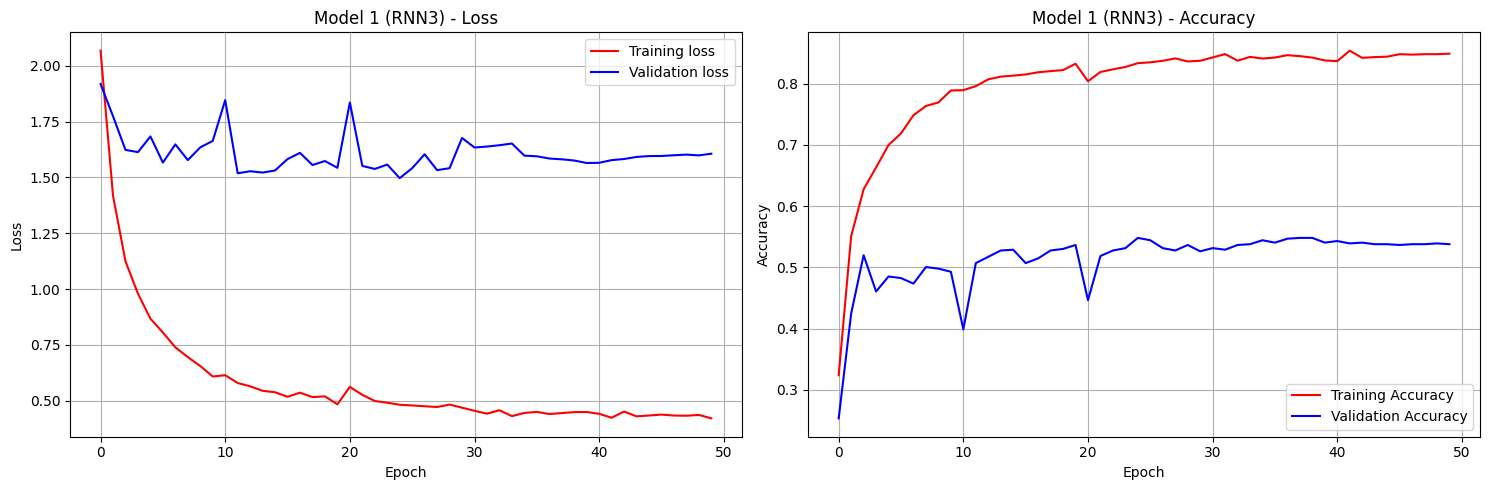

In [ ]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (RNN3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (RNN3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

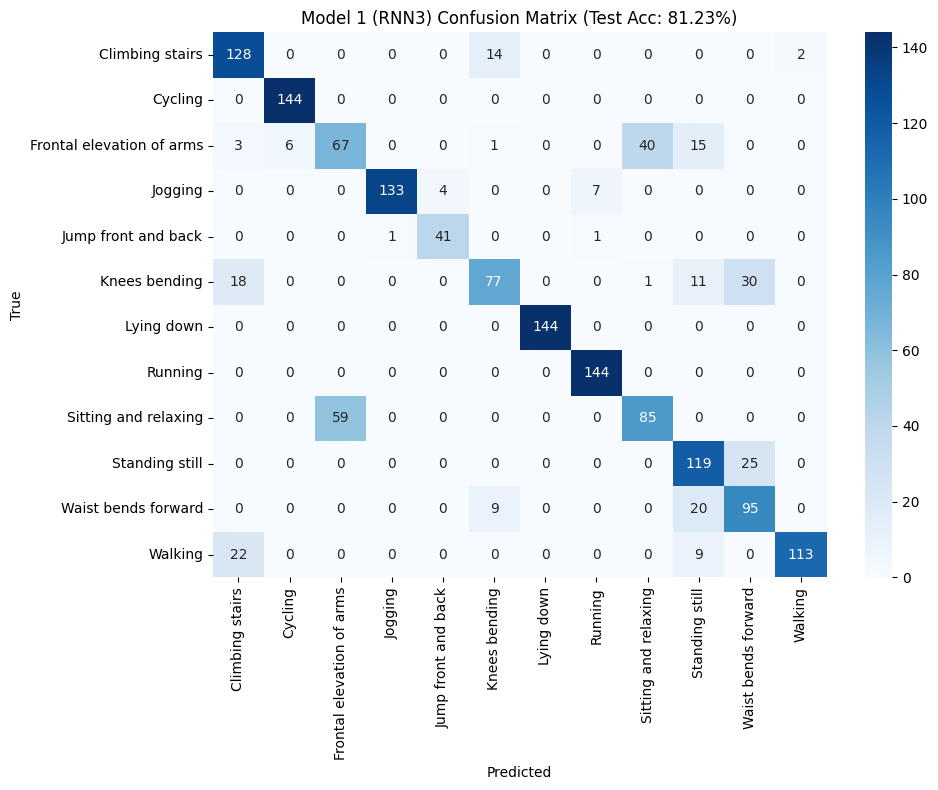

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (RNN3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()